# Constraint Plotting: Manual Parameter Exploration

This notebook shows how to generate constraint plots by **manually defining source parameters**, without running waveform propagation.

## Use Cases:
- Theoretical parameter space exploration
- Quick constraint plot generation
- Testing different source configurations

## What you'll get:
- Constraint plot in parameter space

## What you won't get:
- Spectrogram (requires propagation - see `examples_complete_workflow.ipynb`)

In [16]:
import numpy as np
from inputs.source import Source
from inputs.spectrum import SignalModel
from inputs.experiment import Experiment
from utils.constants import YEAR_TO_SEC, DAY_TO_SEC
from outputs.output_handler import OutputHandler
from plotting.plots import Plot

## Approach 1: Manually Define Source Parameters

Define your source parameters directly without any propagation.

### Example 1: Single Source (1x1 Plot)

In [17]:
# Define source parameters
source = Source(
    Etot=0.01,                  # Total energy [solar masses]
    mass=1e-20,                 # Scalar field mass [eV]
    tstar=1,                    # Burst duration [seconds] (~1 month)
    R=10000.0,                  # Distance [parsecs]
    ULB_type='ALP',             # Type: 'scalar' or 'ALP'
    coupling_type='electron',   # Coupling: 'photon', 'electron', 'gluon'
    coupling_order='quad'       # Order: 'linear' or 'quad'
)

print(f'Source configuration:')
print(f'  mass = {source.mass} eV')
print(f'  R = {source.R} pc')
print(f'  tstar = {source.tstar} s')
print(f'  Etot = {source.Etot / 1.989e66:.4f} solar masses')
print(f'  coupling_type = {source.coupling_type}')
print(f'  coupling_order = {source.coupling_order}')

Source configuration:
  mass = 1e-20 eV
  R = 10000.0 pc
  tstar = 1.0 s
  Etot = 0.0056 solar masses
  coupling_type = electron
  coupling_order = ALP


#### Configure Experiment and Generate Constraint Plot

In [18]:
# Define experiment parameters
experiment = Experiment(
    integration_time=DAY_TO_SEC,      # Integration time for transient search
    integration_time_DM=YEAR_TO_SEC,  # Integration time for DM search
    sensitivity=1e-17,                 # Fractional frequency sensitivity
    time_delays={'day': DAY_TO_SEC, 'year': YEAR_TO_SEC}  # Time delay measurements
)

# Create signal model
signal_model = SignalModel(source=source, experiment=experiment)

print('Signal model created successfully')

Signal model created successfully


Constraint plot saved to constraints_manual.png


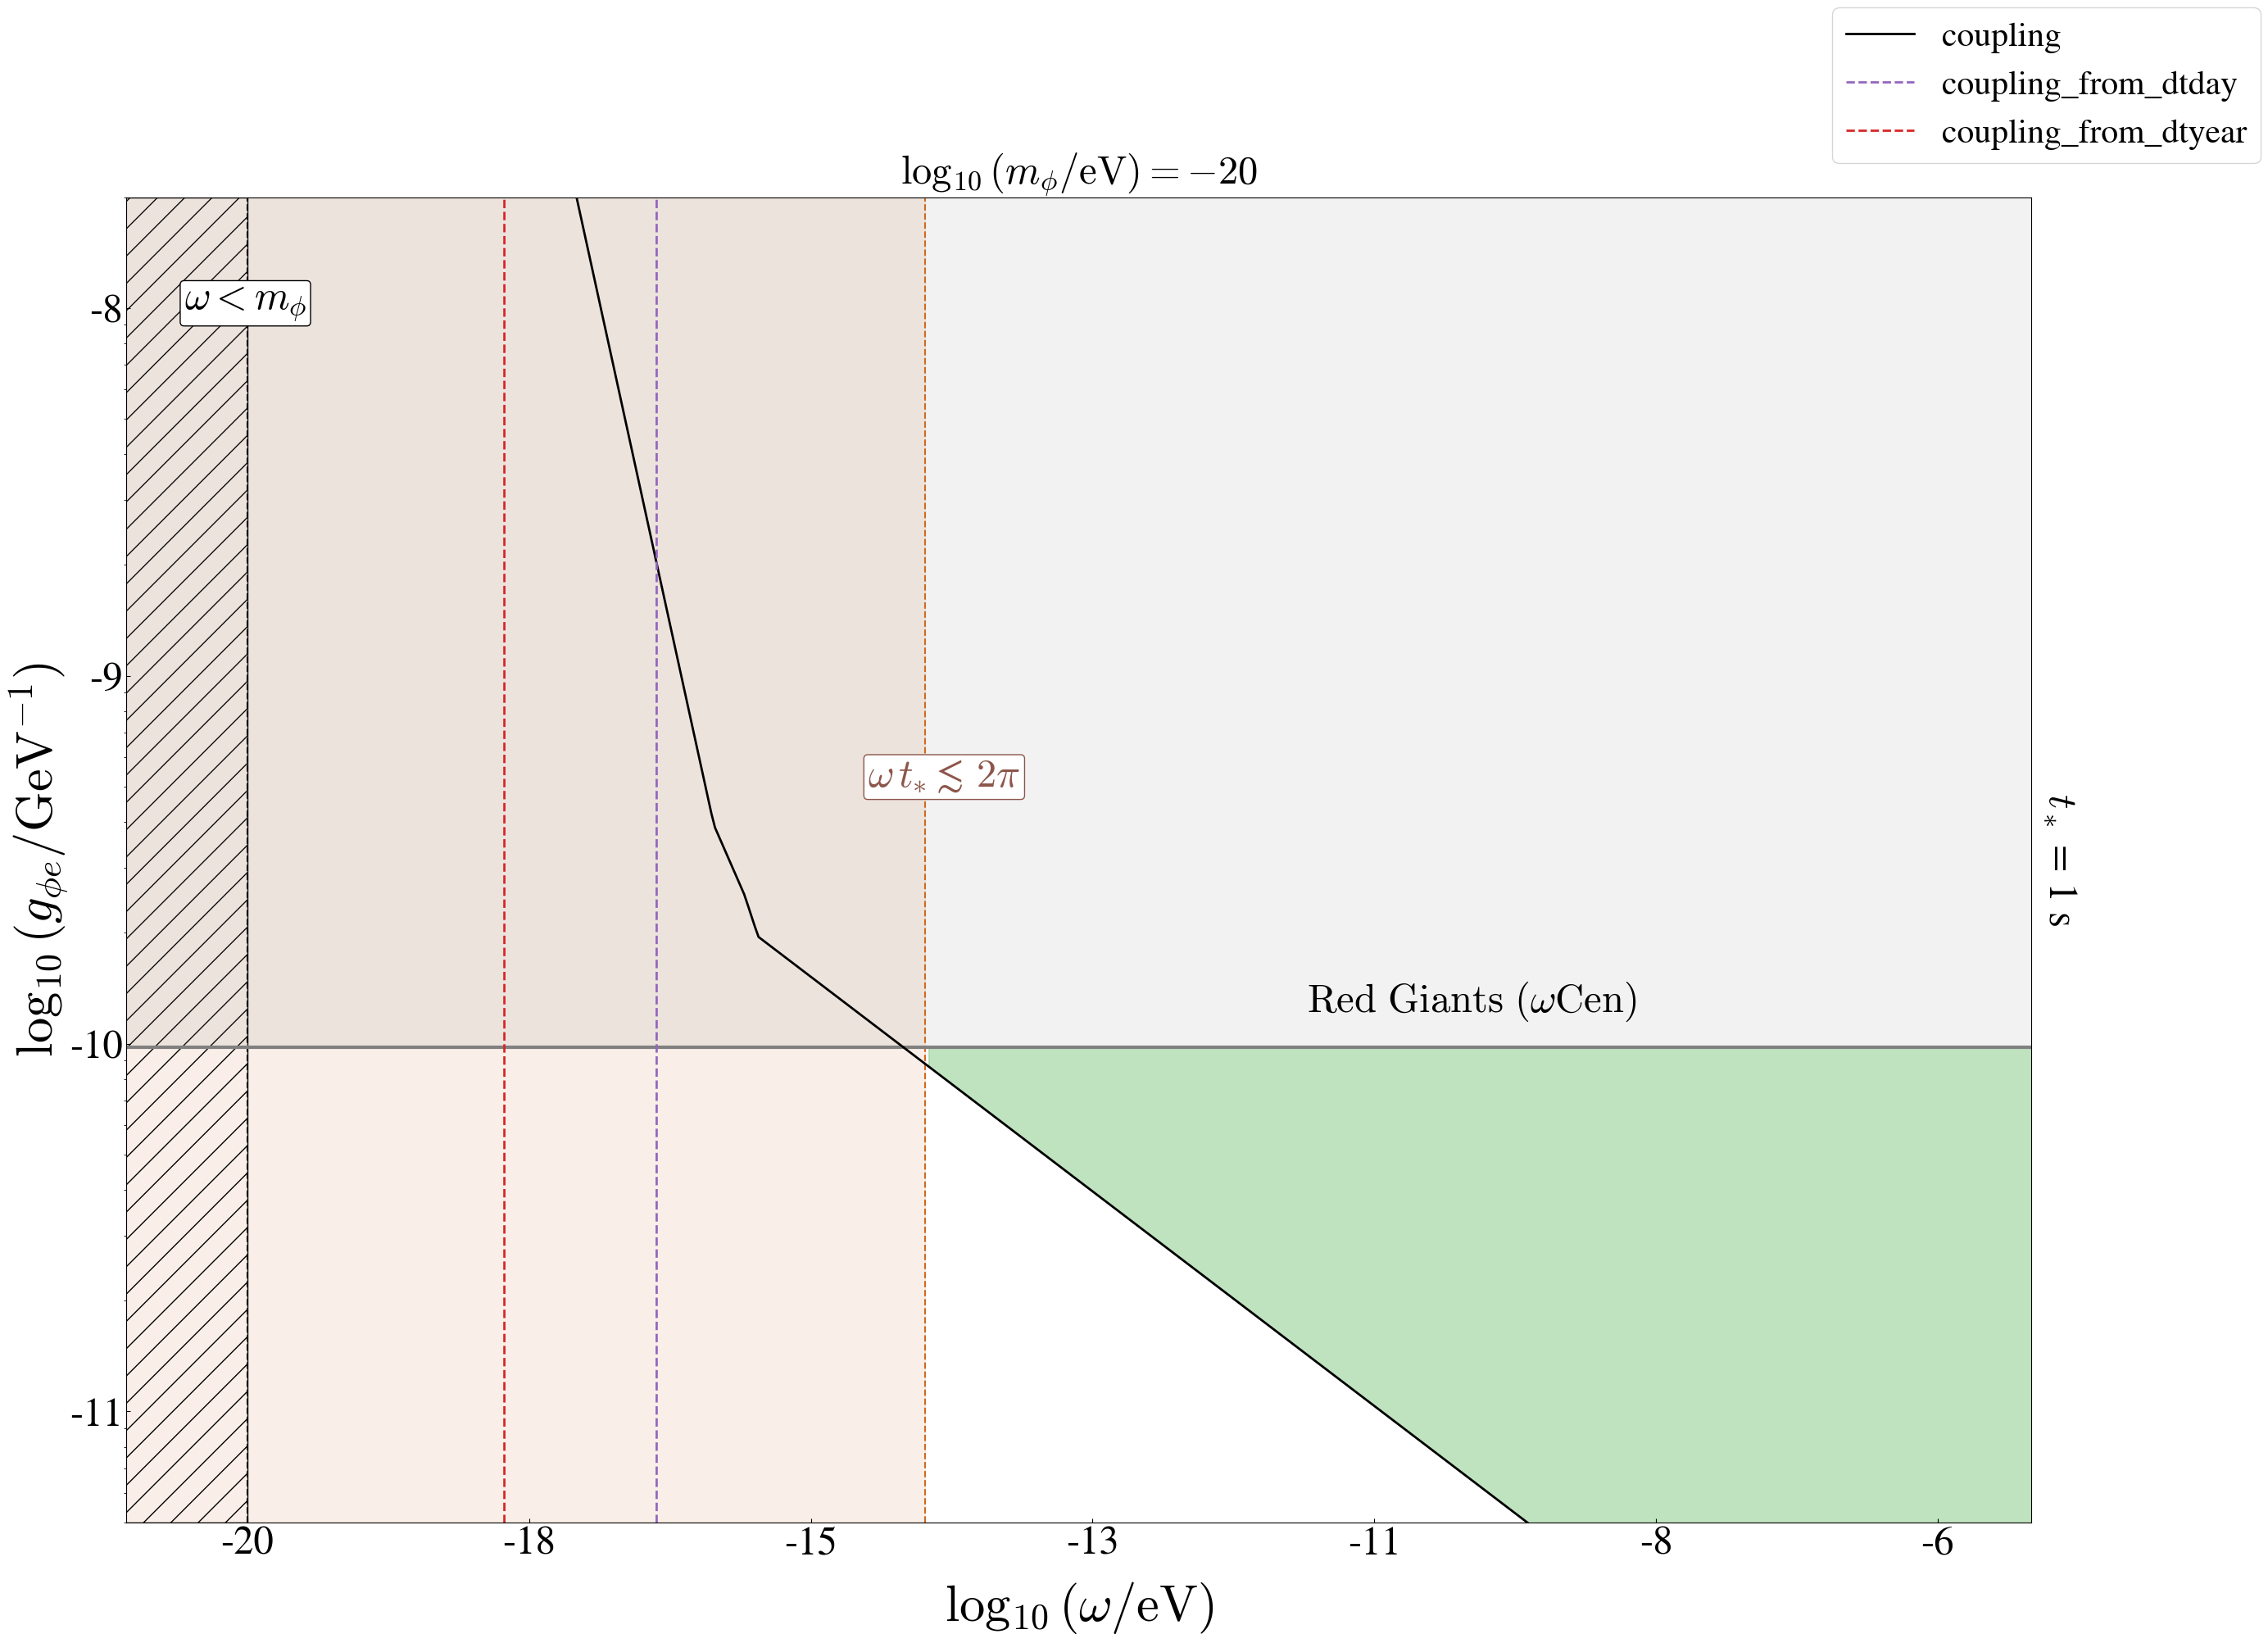

In [19]:
# Generate constraint plot
plot = Plot(
    xlims=(1e-21, 6e-6),   # Energy range [eV]
    ylims=(5e-12, 2e-8),   # Coupling range
    exclude_mass=False,
    include_legend=True
)

output = OutputHandler(plot)
output.plot_parameter_space(
    source, 
    signal_model, 
    plot, 
    save_path='constraints_manual.png',
)

print('Constraint plot saved to constraints_manual.png')

## Example 2: 2x2 Parameter Grid

Create a grid of constraint plots varying mass and burst duration:

In [20]:
# Define parameter grid
masses = [1e-20, 1e-15]  # Two different masses [eV]
times = [1, 100]         # Two different burst durations [seconds]

# Create 2x2 grid of sources
sources_grid = [
    [Source(
        Etot=0.01, 
        mass=m, 
        tstar=t, 
        R=1e4, 
        ULB_type='ALP', 
        coupling_type='electron'
    ) for m in masses] 
    for t in times
]

# Create corresponding signal models
signal_models_grid = [
    [SignalModel(source=s, experiment=experiment) for s in row] 
    for row in sources_grid
]

print(f'Created 2x2 grid with:')
print(f'  Masses: {masses} eV')
print(f'  Burst durations: {times} s')

Created 2x2 grid with:
  Masses: [1e-20, 1e-15] eV
  Burst durations: [1, 100] s


2x2 constraint plot saved to constraints_2x2.png


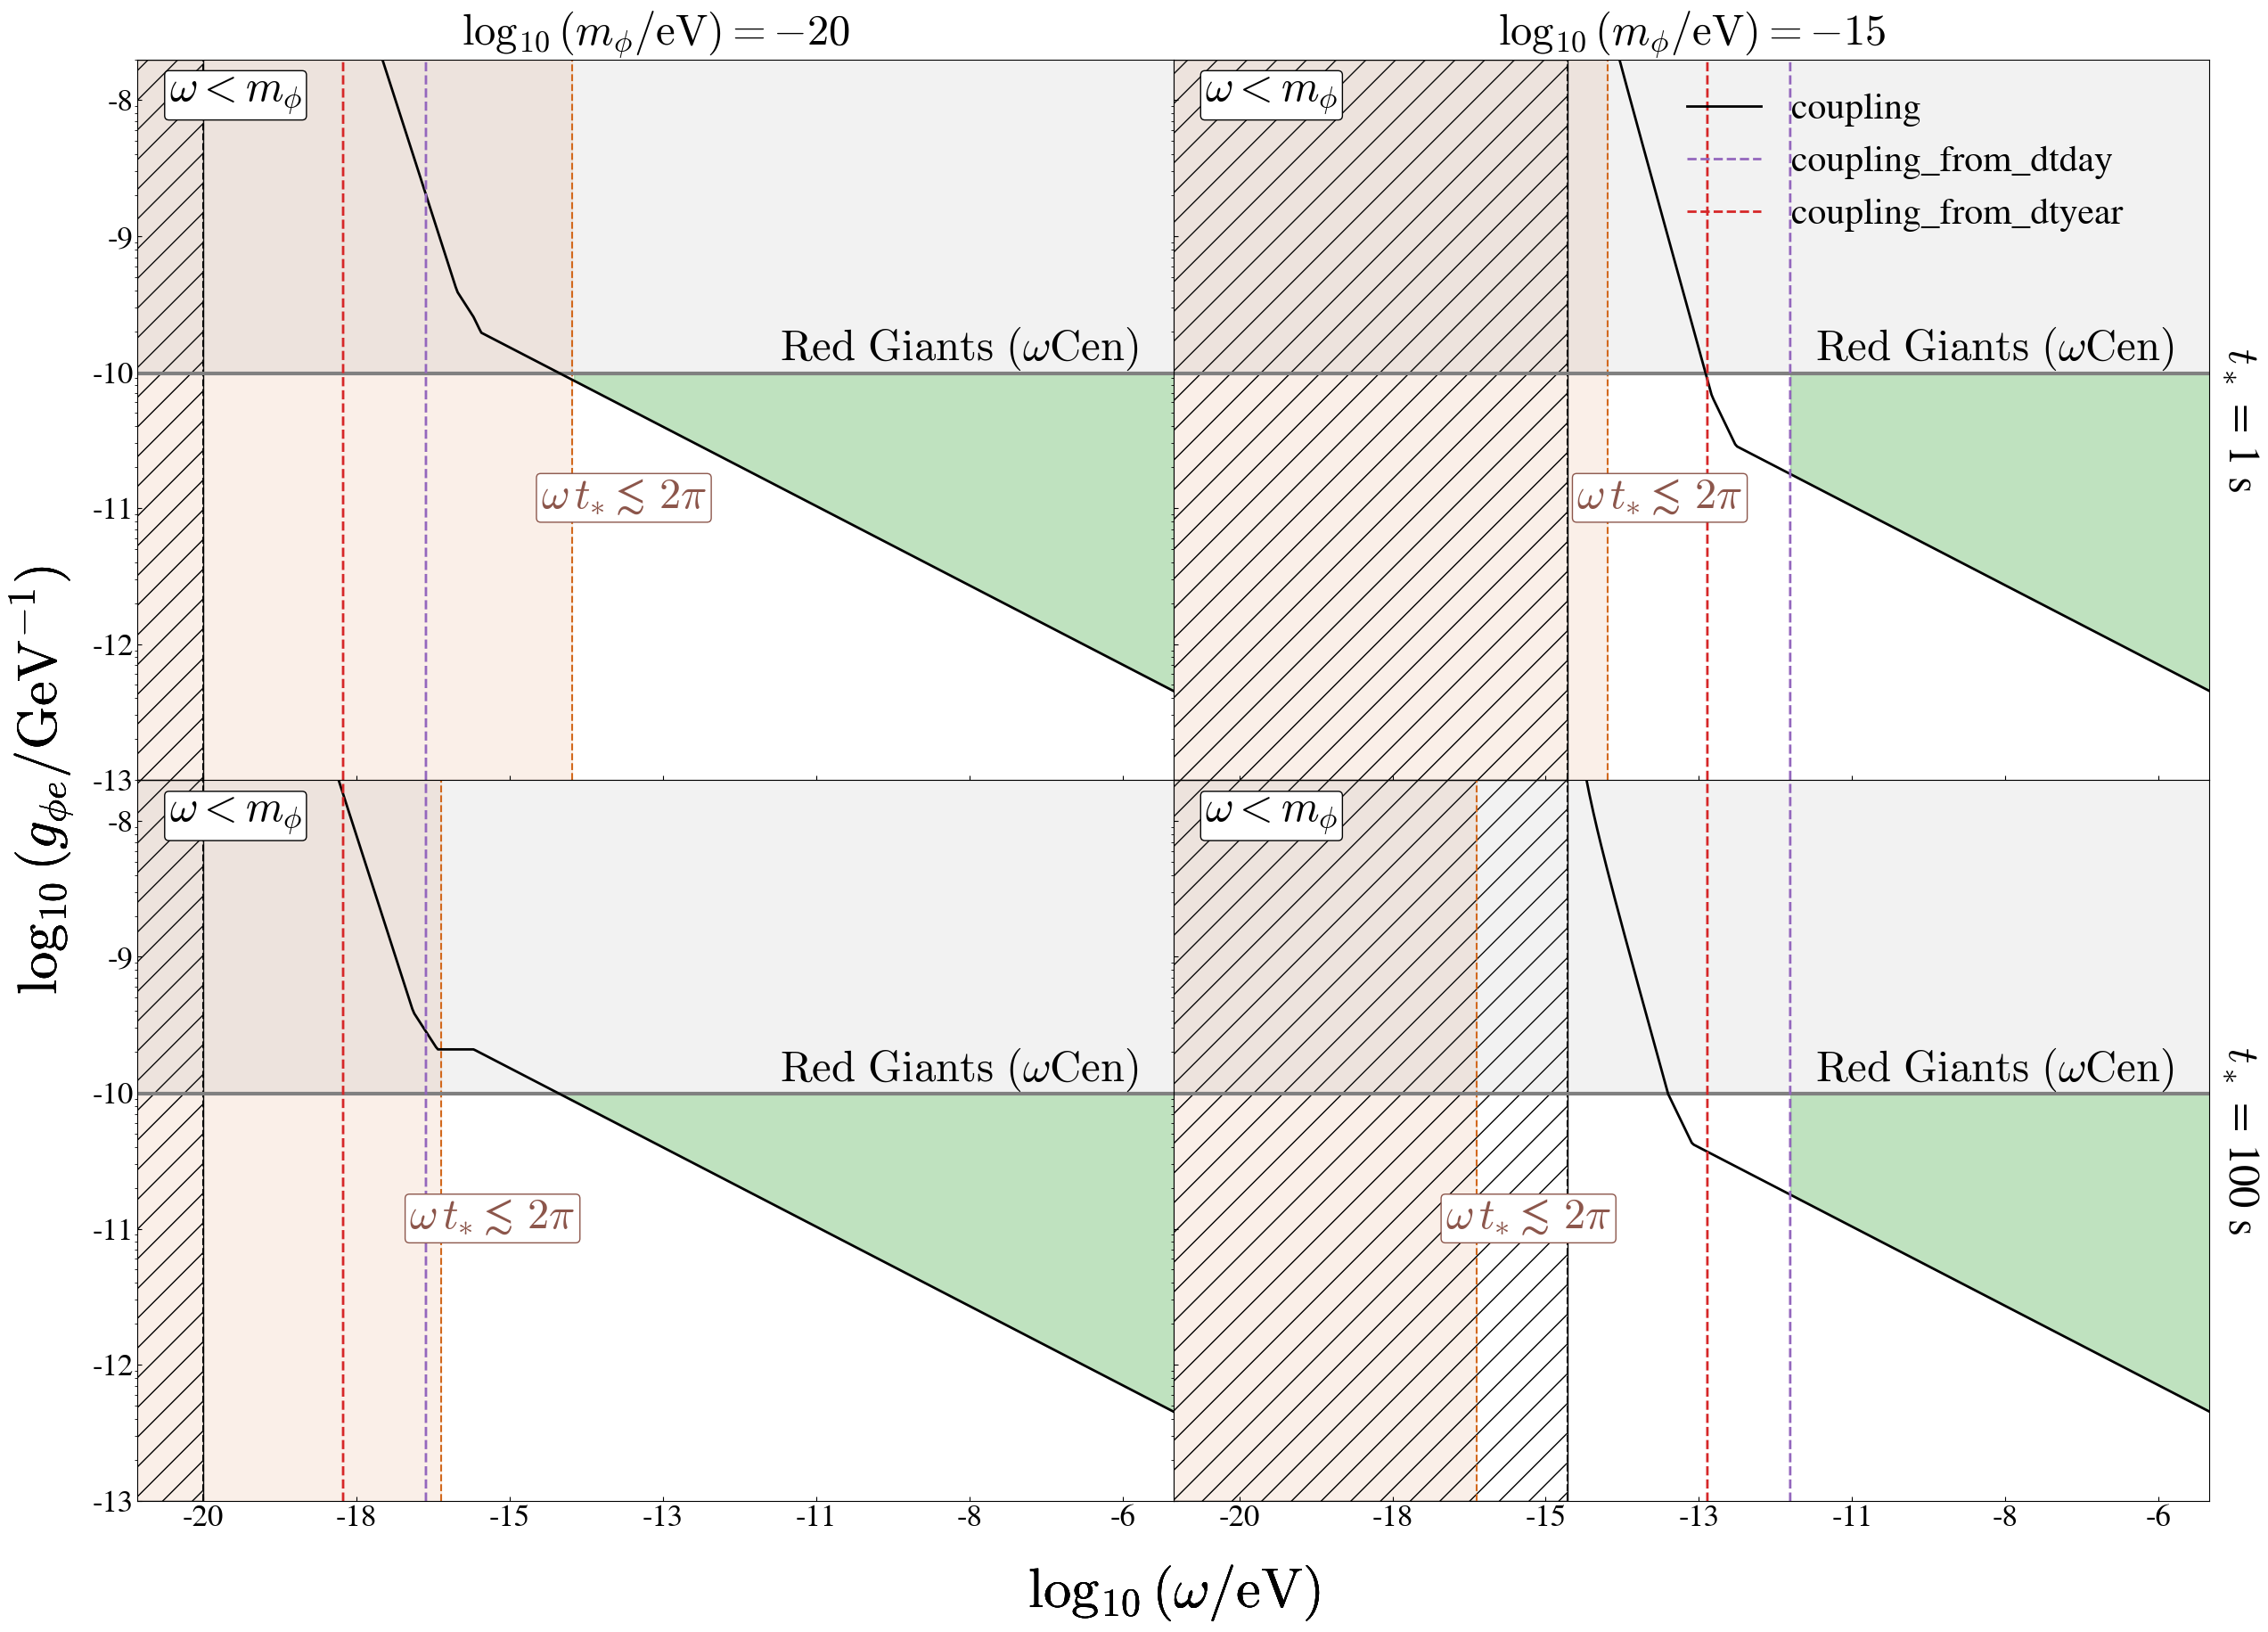

In [21]:
# Configure plot with custom legend position
legend_config = {
    'frameon': False,
    'bbox_to_anchor': (0.88, 0.88)
}

plot_2x2 = Plot(
    xlims=(1e-21, 6e-6), 
    ylims=(1e-13, 2e-8), 
    exclude_mass=False, 
    include_legend=True, 
    legend_config=legend_config
)

output_2x2 = OutputHandler(plot_2x2)
output_2x2.plot_parameter_space(
    sources_grid, 
    signal_models_grid, 
    plot_2x2, 
    save_path='constraints_2x2.png'
)

print('2x2 constraint plot saved to constraints_2x2.png')

---

## Optional: Load from Previously Saved Parameters

If you ran `examples_complete_workflow.ipynb` and exported parameters, you can load them here:

In [22]:
from waveform.propagation import load_source_from_file

# Load source from parameter file (if it exists)
try:
    source_from_file = load_source_from_file('bosenova.param', ULB_type='scalar')
    
    print('Loaded source from bosenova.param:')
    print(f'  mass = {source_from_file.mass} eV')
    print(f'  R = {source_from_file.R} pc')
    print(f'  tstar = {source_from_file.tstar} s')
    print(f'  Etot = {source_from_file.Etot / 1.989e66:.4f} solar masses')
    print(f'  coupling_type = {source_from_file.coupling_type}')
    print(f'  coupling_order = {source_from_file.coupling_order}')
    
    # Generate constraint plot with loaded parameters
    signal_model_from_file = SignalModel(source=source_from_file, experiment=experiment)
    output.plot_parameter_space(
        source_from_file, 
        signal_model_from_file, 
        plot, 
        save_path='constraints_from_file.png'
    )
    
    print('\nConstraint plot saved to constraints_from_file.png')
    
except FileNotFoundError:
    print('No parameter file found. Run examples_complete_workflow.ipynb first to generate bosenova.param')

No parameter file found. Run examples_complete_workflow.ipynb first to generate bosenova.param


---

## Summary

This notebook demonstrated manual parameter exploration with:
1. **Example 1: Single source (1x1 plot)** - Basic constraint plot generation
2. **Example 2: Parameter grid (2x2 plot)** - Varying mass and burst duration
3. **Optional file loading** - Resume from propagation results

For the **complete workflow** including spectrogram generation, see `examples_complete_workflow.ipynb`.